**Task 1 — Data Loading & Exploration**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('Housing.csv')

In [5]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [7]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [6]:
df.shape

(545, 13)

In [8]:
target = "price"
features = df.drop(target, axis=1)

print("target columns : ", target)
print("Features Columns: ", list(features.columns))

target columns :  price
Features Columns:  ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [10]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


*There is no missing Values*

**Task 2 — Data Cleaning**

In [11]:
df.duplicated().sum()

np.int64(0)

*There is no Duplicated value so no need to drop*

**Check Categorical columns**

In [12]:
df.select_dtypes(include = 'object').columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

**Applying ONE HOT Encoding**

In [13]:
df_encoded = pd.get_dummies(df, drop_first= True)

In [14]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


*We need to change its Data type so that all selceted columns converted into 1 or 0*

In [19]:
df_encoded[col] = df_encoded[col].astype(int)

df_encoded.dtypes

,0
price,int64
area,int64
bedrooms,int64
bathrooms,int64
stories,int64
parking,int64
mainroad_yes,int64
guestroom_yes,int64
basement_yes,int64
hotwaterheating_yes,int64


In [20]:
df_encoded

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,1,1,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,2,1,0,1,0,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0


In [21]:
corr = df_encoded.corr(numeric_only=True)

price_corr = corr["price"].sort_values(ascending=False)

print(price_corr)

price                              1.000000
area                               0.535997
bathrooms                          0.517545
airconditioning_yes                0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea_yes                       0.329777
mainroad_yes                       0.296898
guestroom_yes                      0.255517
basement_yes                       0.187057
hotwaterheating_yes                0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64


In [22]:
X = df_encoded.drop('price', axis=1)
y = df_encoded['price']

**Task 3 — Model Building**

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error , root_mean_squared_error , r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [25]:
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

In [26]:
model = LinearRegression()

In [27]:
model.fit(X_train, y_train)

LinearRegression()

In [28]:
model_pred = model.predict(X_test)

In [29]:
model_pred

array([5164653.90033967, 7224722.29802166, 3109863.24240338,
       4612075.32722559, 3294646.25725955, 3532275.09556558,
       5611774.56836476, 6368145.98732718, 2722856.95689985,
       2629405.61585782, 9617039.5031558 , 2798087.30447888,
       3171096.76847063, 3394639.09125528, 3681088.65424275,
       5263187.74621485, 3035963.47612384, 4786122.8004005 ,
       4349551.9200572 , 3572362.09930451, 5774875.21395649,
       5886993.57919883, 2730836.19518458, 4727316.47323635,
       5244847.52716801, 7555324.21605603, 3220790.84680268,
       5191898.79934206, 8143726.91009786, 3398814.09825035,
       6490693.05027925, 3315105.9074781 , 6708457.36761326,
       4201738.21071676, 3557571.06735186, 5836974.50478626,
       4808660.67448475, 4362878.73613261, 3191242.95701508,
       4596554.93225238, 4566042.86048411, 3517779.52374148,
       7205844.79365835, 3983597.27861103, 3749338.70271056,
       4274731.09125895, 6757442.10783741, 4037320.43665851,
       3769334.90397126,

In [32]:
model_mae = mean_absolute_error(y_test, model_pred)
model_rmse = np.sqrt(mean_squared_error(y_test, model_pred))
model_r2 = r2_score(y_test, model_pred)

In [34]:
print("Mean Absolute Error:",model_mae)
print("Root Mean Squared Error:",model_rmse)
print("R2 Score:",model_r2)

Mean Absolute Error: 970043.4039201636
Root Mean Squared Error: 1324506.9600914386
R2 Score: 0.6529242642153184


In [51]:
model_RF = RandomForestRegressor(n_estimators=200, random_state=42)
model_RF.fit(X_train, y_train)


RandomForestRegressor(n_estimators=200, random_state=42)

In [52]:
y_pred_RF = model_RF.predict(X_test)

In [53]:
y_pred_RF

array([ 5433085.        ,  7194355.        ,  3779741.875     ,
        4536595.        ,  3659967.5       ,  3468290.        ,
        5065305.        ,  5150705.        ,  2573830.        ,
        2910027.75      , 10178119.7       ,  3321687.08333333,
        2995638.33333333,  3467730.        ,  3661315.        ,
        3975300.        ,  3244179.16666667,  4860537.5       ,
        3646720.        ,  4079757.5       ,  5529527.5       ,
        5893860.        ,  2996020.41666667,  3717070.        ,
        4711455.        ,  6509895.        ,  3209885.        ,
        4617480.        ,  6347425.        ,  3282580.        ,
        5655825.        ,  3189900.        ,  6722590.        ,
        4330340.        ,  2998800.        ,  6450220.        ,
        4758565.        ,  3711015.        ,  3045140.        ,
        4231360.        ,  4087895.        ,  2798436.66666667,
        7325780.        ,  4196605.        ,  3989055.        ,
        4327960.        ,  7271110.     

In [36]:
model_RF_mae = mean_absolute_error(y_test, y_pred_RF)
model_RF_rmse = np.sqrt(mean_squared_error(y_test, y_pred_RF))
model_RF_r2 = r2_score(y_test, y_pred_RF)

In [37]:
print("Mean Absolute Error:",model_RF_mae)
print("Root Mean Squared Error:",model_RF_rmse)
print("R2 Score:",model_RF_r2)

Mean Absolute Error: 1013968.579587156
Root Mean Squared Error: 1398115.6668385956
R2 Score: 0.6132752494107068


In [40]:
Results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [model_mae, model_RF_mae],
    'RMSE': [model_rmse, model_RF_rmse],
    'R2 Score': [model_r2, model_RF_r2]
})
print(Results)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  9.700434e+05  1.324507e+06  0.652924
1      Random Forest  1.013969e+06  1.398116e+06  0.613275


**Task 4 — Visualization (Minimum 3 charts)**

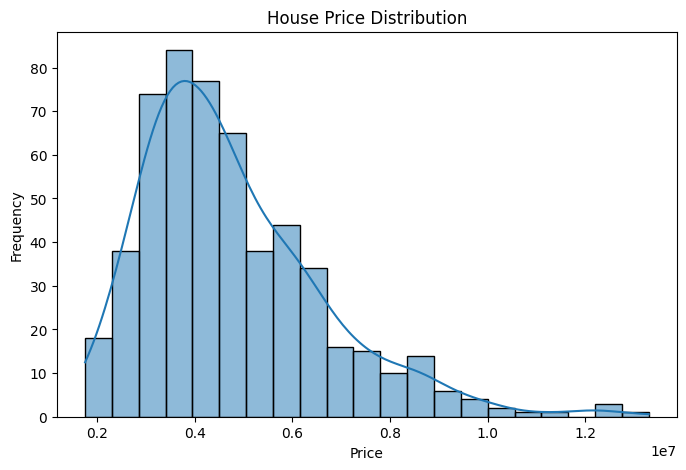

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)

plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

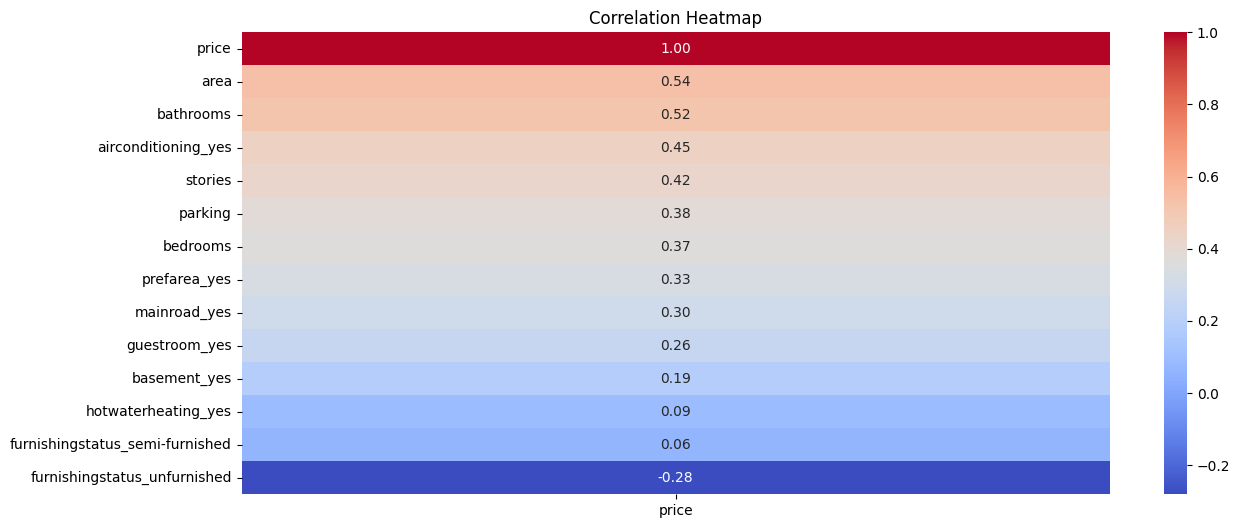

In [48]:
plt.figure(figsize=(14,6))

sns.heatmap(price_corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

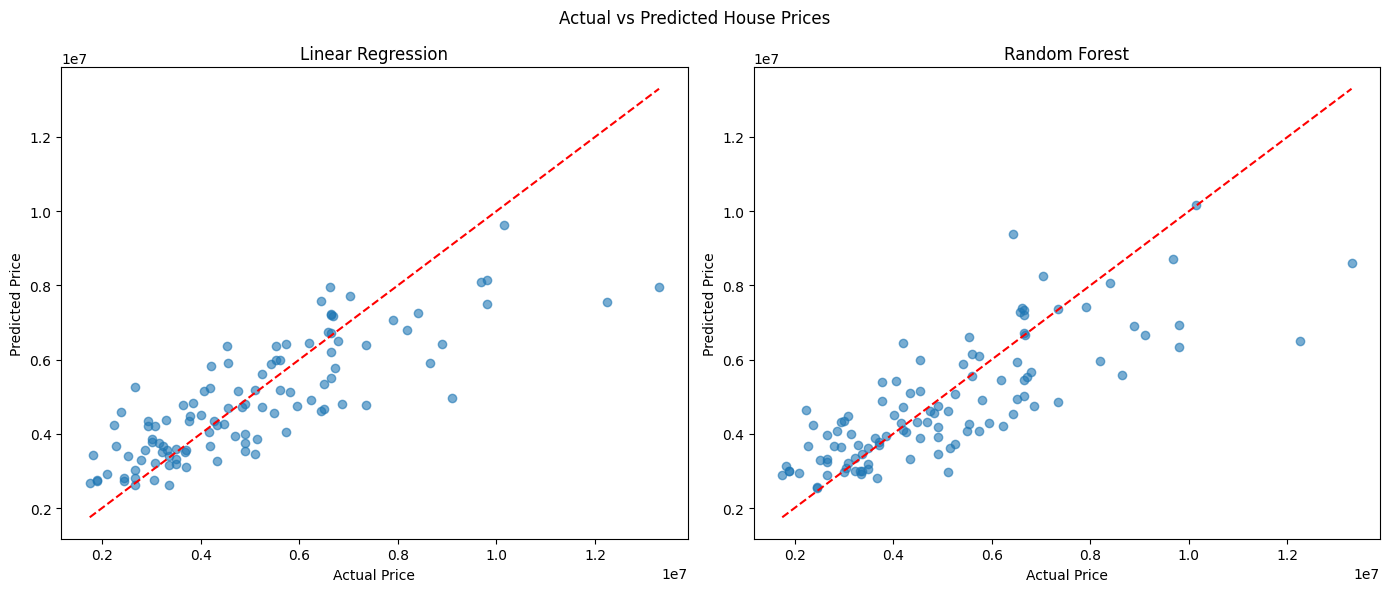

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Linear Regression
axes[0].scatter(y_test, model_pred, alpha=0.6)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual Price")
axes[0].set_ylabel("Predicted Price")

# Random Forest
axes[1].scatter(y_test, y_pred_RF, alpha=0.6)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual Price")
axes[1].set_ylabel("Predicted Price")

plt.suptitle("Actual vs Predicted House Prices")

plt.tight_layout()


plt.show()

In [55]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_RF.feature_importances_
}).sort_values(by='Importance', ascending=False)

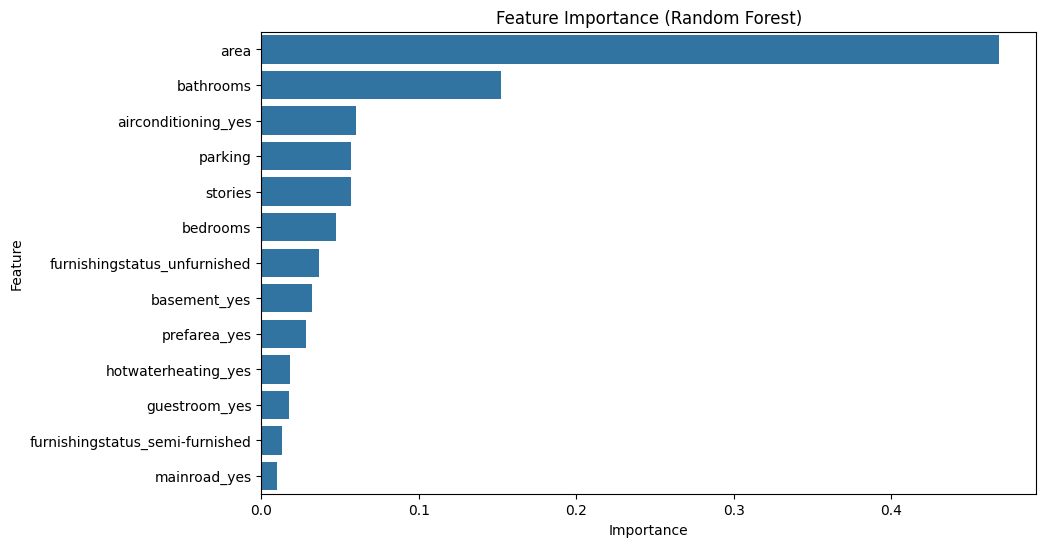

In [56]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title("Feature Importance (Random Forest)")

plt.show()

**Task 5 — Insights & Summary**

*The analysis showed that area, bathrooms, air conditioning, and parking were the most influential factors affecting house prices.*

 *Interestingly, the number of bathrooms had a stronger impact on price than the number of bedrooms, suggesting that buyers value comfort and amenities highly.*

 *The Random Forest model produced more accurate predictions than Linear Regression and was able to estimate house prices effectively.
 If Random Forest R² ≈ 0.85–0.90:*

*"The Random Forest model explained approximately 85–90% of the variation in house prices, demonstrating strong predictive capability."*

*If R² > 0.90:*

*"The Random Forest model explained more than 90% of the variation in house prices, indicating excellent prediction accuracy."*

*Another key finding was that houses located in preferred areas and near main roads tended to have higher prices. Based on these results, real estate businesses should focus on highlighting property size, amenities, and location advantages when marketing homes.*